# 04 DPO Review

Purpose: launch the Stage 2 DPO run from the Drive-backed source tree, inspect the saved loss and reward traces, evaluate SFT vs DPO on the held-out manifest, and produce one consolidated baseline vs SFT vs DPO report.

Preconditions:
- Run `00_colab_setup.ipynb` first.
- Run `02_sft_review.ipynb` at least once so the SFT manifest and adapter metadata exist.
- If you need fresh preference pairs, run `03_preference_pair_audit.ipynb` before this notebook.


In [1]:
from pathlib import Path

SOURCE_ROOT = Path('/content/drive/MyDrive/json-ft-source')
RUNTIME_ROOT = Path('/content/drive/MyDrive/json-ft-runs')

PROFILE = 'full'
PREFERENCE_RUN_NAME = 'pref-full-colab'
DPO_RUN_NAME = 'dpo-full-colab'
SFT_EVAL_RUN_NAME = 'sft-qwen2.5-1.5b-qlora-v1_eval'
DPO_EVAL_RUN_NAME = f'{DPO_RUN_NAME}_eval'
COMPARISON_RUN_NAME = f'{DPO_RUN_NAME}_comparison'

BASELINE_RUN_NAME = 'baseline-qwen2.5-1.5b'
SFT_MANIFEST_NAME = 'sft-qwen2.5-1.5b-qlora-v1_adapter_manifest.json'

PREFERENCE_MANIFEST = RUNTIME_ROOT / 'persistent' / 'preferences' / PREFERENCE_RUN_NAME / f'{PREFERENCE_RUN_NAME}_dpo_pairs.jsonl'
SFT_MANIFEST = SOURCE_ROOT / 'artifacts' / 'checkpoints' / SFT_MANIFEST_NAME
DPO_MANIFEST = SOURCE_ROOT / 'artifacts' / 'checkpoints' / f'{DPO_RUN_NAME}_dpo_manifest.json'

EVAL_MANIFEST = SOURCE_ROOT / 'data' / 'manifests' / 'support_tickets_eval_manifest.jsonl'
BASELINE_METRICS = SOURCE_ROOT / 'artifacts' / 'metrics' / f'{BASELINE_RUN_NAME}_metrics.json'
BASELINE_PREDICTIONS = SOURCE_ROOT / 'artifacts' / 'reports' / f'{BASELINE_RUN_NAME}_predictions.jsonl'

SOURCE_ROOT, RUNTIME_ROOT, PREFERENCE_MANIFEST, SFT_MANIFEST


(PosixPath('/content/drive/MyDrive/json-ft-source'),
 PosixPath('/content/drive/MyDrive/json-ft-runs'),
 PosixPath('/content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_dpo_pairs.jsonl'),
 PosixPath('/content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-qwen2.5-1.5b-qlora-v1_adapter_manifest.json'))

In [2]:
required_paths = [
    SOURCE_ROOT / 'scripts' / 'train_dpo.py',
    SOURCE_ROOT / 'scripts' / 'eval_model.py',
    SOURCE_ROOT / 'scripts' / 'compare_stages.py',
    SOURCE_ROOT / 'configs' / 'dpo.yaml',
    EVAL_MANIFEST,
    PREFERENCE_MANIFEST,
    SFT_MANIFEST,
    BASELINE_METRICS,
    BASELINE_PREDICTIONS,
]

missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError('Missing required DPO inputs:\n' + '\n'.join(str(path) for path in missing))

print('All DPO review prerequisites are present.')


All DPO review prerequisites are present.


In [3]:
import subprocess

command = [
    'python',
    str(SOURCE_ROOT / 'scripts' / 'train_dpo.py'),
    '--config',
    str(SOURCE_ROOT / 'configs' / 'dpo.yaml'),
    '--profile',
    PROFILE,
    '--run-name',
    DPO_RUN_NAME,
    '--runtime-root',
    str(RUNTIME_ROOT),
    '--preference-manifest',
    str(PREFERENCE_MANIFEST),
    '--source-sft-manifest',
    str(SFT_MANIFEST),
    '--mirror-metrics-to-repo',
    '--mirror-plots-to-repo',
    '--mirror-checkpoint-manifest-to-repo',
    '--promote-latest',
]

print('Running command:')
print(' '.join(command))
result = subprocess.run(command, capture_output=True, text=True, check=False)
print('\nSTDOUT:\n')
print(result.stdout)
if result.stderr:
    print('\nSTDERR:\n')
    print(result.stderr)
if result.returncode != 0:
    raise RuntimeError(f'DPO training failed with exit code {result.returncode}')


Running command:
python /content/drive/MyDrive/json-ft-source/scripts/train_dpo.py --config /content/drive/MyDrive/json-ft-source/configs/dpo.yaml --profile full --run-name dpo-full-colab --runtime-root /content/drive/MyDrive/json-ft-runs --preference-manifest /content/drive/MyDrive/json-ft-runs/persistent/preferences/pref-full-colab/pref-full-colab_dpo_pairs.jsonl --source-sft-manifest /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-qwen2.5-1.5b-qlora-v1_adapter_manifest.json --mirror-metrics-to-repo --mirror-plots-to-repo --mirror-checkpoint-manifest-to-repo --promote-latest

STDOUT:

DPO training
Config: /content/drive/MyDrive/json-ft-source/configs/dpo.yaml
Profile: full
Run name: dpo-full-colab
Base model: Qwen/Qwen2.5-1.5B-Instruct
Policy init: Qwen/Qwen2.5-1.5B-Instruct
Reference strategy: adapter
Source adapter path: /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-qwen2.5-1.5b-qlora-v1/adapter
Preference manifest: /content/drive/MyDrive/json-f

In [4]:
import json

dpo_summary_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_RUN_NAME}_dpo_summary.json'
dpo_history_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_RUN_NAME}_dpo_history.json'

dpo_summary = json.loads(dpo_summary_path.read_text(encoding='utf-8'))
dpo_history = json.loads(dpo_history_path.read_text(encoding='utf-8'))

dpo_summary


{'adapter_path': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab/adapter',
 'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'checkpoint_root': '/content/drive/MyDrive/json-ft-runs/persistent/checkpoints/dpo/dpo-full-colab',
 'config_path': '/content/drive/MyDrive/json-ft-source/configs/dpo.yaml',
 'eval_loss_curve_path': None,
 'eval_preference_manifest': None,
 'eval_record_count': 0,
 'history_artifacts': {'eval_loss_curve_path': None,
  'extra_plot_paths': {'rewards_accuracies': '/content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_accuracies_curve.png',
   'rewards_chosen': '/content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_chosen_curve.png',
   'rewards_margins': '/content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_margins_curve.png',
   'rewards_rejected': '/content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_rejected_curve.png'},
  'history_

training_loss: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_loss_curve.png


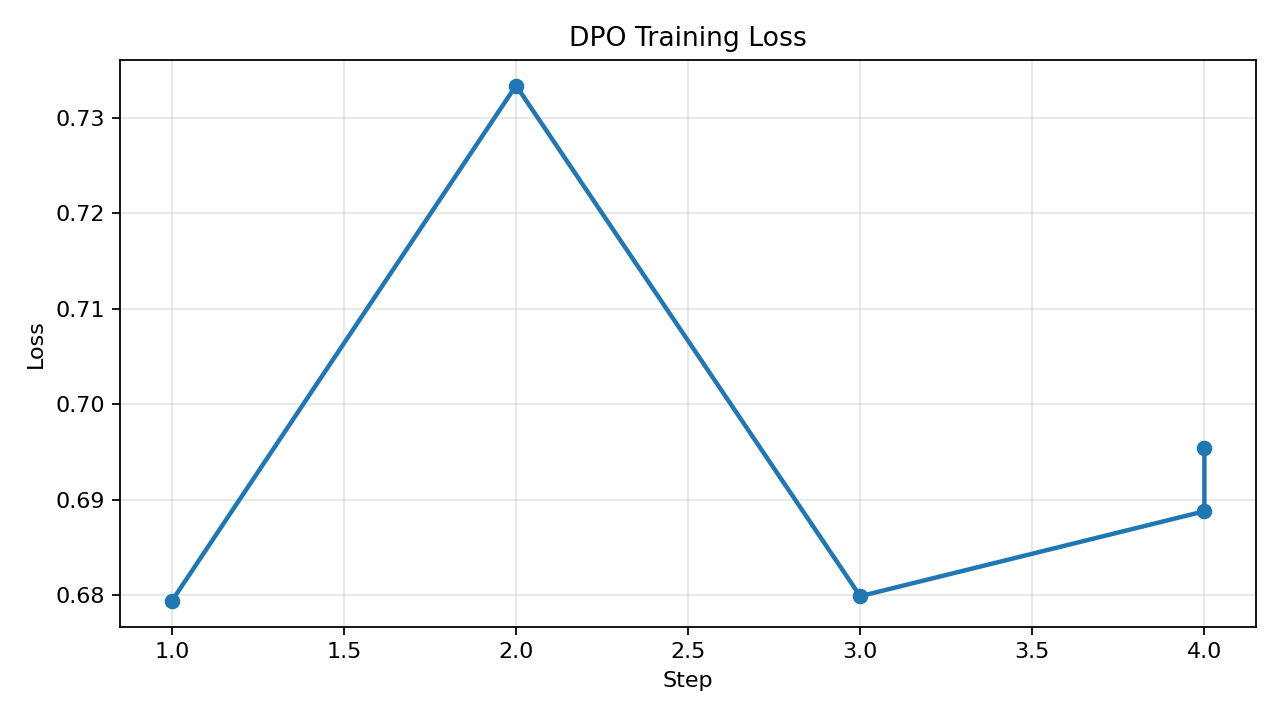

rewards_accuracies: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_accuracies_curve.png


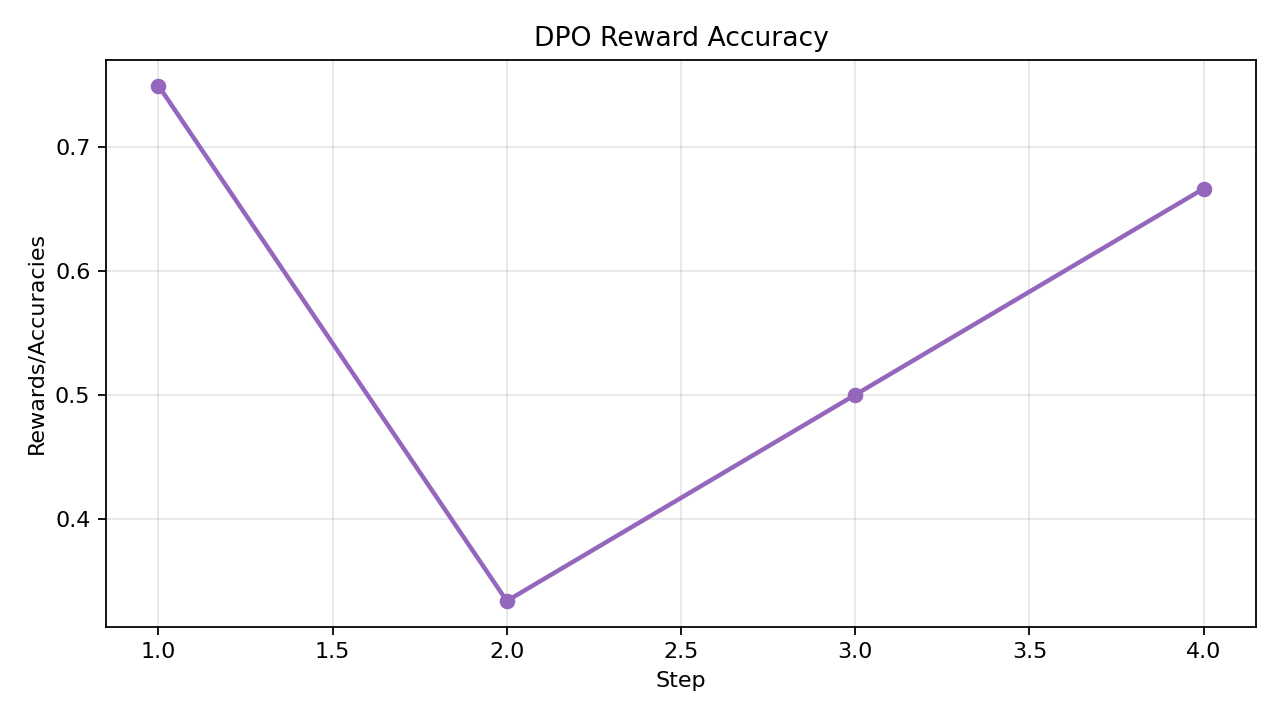

rewards_chosen: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_chosen_curve.png


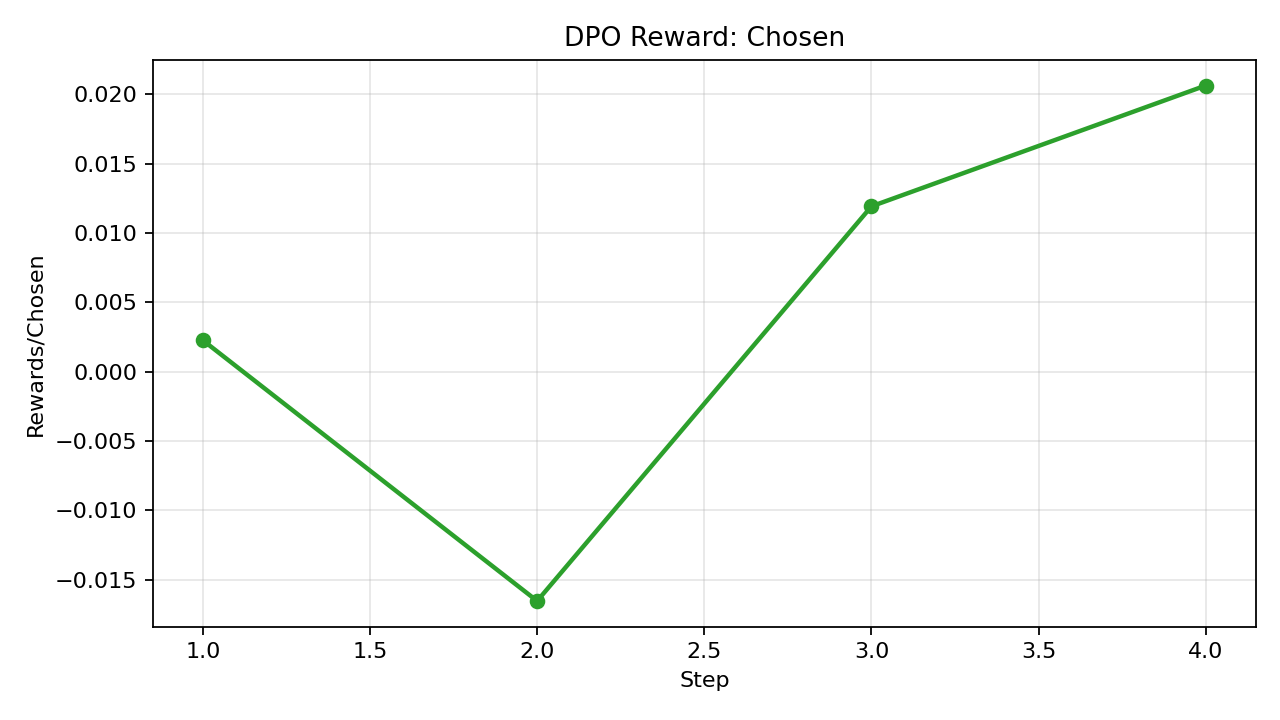

rewards_margins: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_margins_curve.png


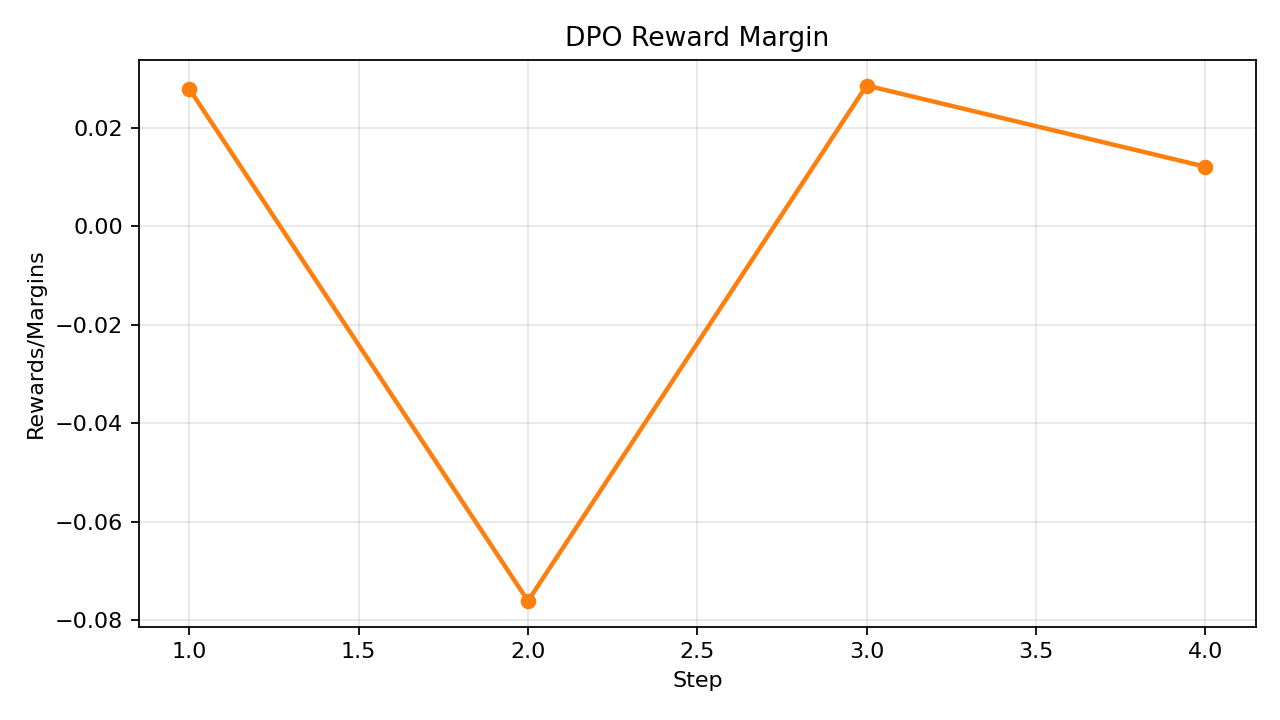

rewards_rejected: /content/drive/MyDrive/json-ft-runs/persistent/plots/dpo-full-colab_dpo_rewards_rejected_curve.png


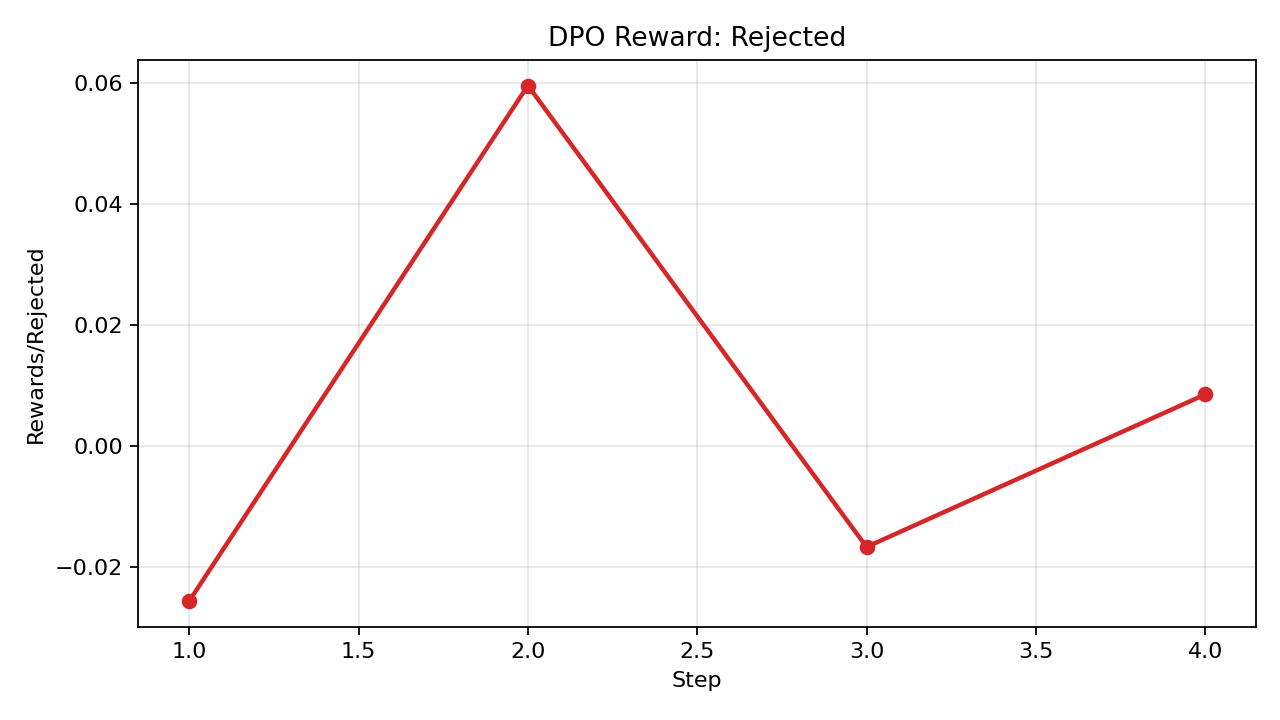

In [5]:
from IPython.display import Image, display
import sys

history_artifacts = dpo_summary.get('history_artifacts') or {}
loss_curve_path = history_artifacts.get('loss_curve_path') or dpo_summary.get('loss_curve_path')
eval_loss_curve_path = history_artifacts.get('eval_loss_curve_path') or dpo_summary.get('eval_loss_curve_path')
reward_plots = history_artifacts.get('extra_plot_paths') or dpo_summary.get('reward_plot_paths') or {}

needs_regen = False
if loss_curve_path and not Path(loss_curve_path).exists() and (dpo_history.get('raw_log_history') or []):
    needs_regen = True

if needs_regen:
    sys.path.insert(0, str(SOURCE_ROOT / 'src'))
    from json_ft.training_plots import PlotSpec, write_training_history_and_plots

    reward_spec_defaults = {
        'rewards/chosen': ('DPO Reward: Chosen', '#2ca02c'),
        'rewards/rejected': ('DPO Reward: Rejected', '#d62728'),
        'rewards/accuracies': ('DPO Reward Accuracy', '#9467bd'),
        'rewards/margins': ('DPO Reward Margin', '#ff7f0e'),
    }
    regenerated = write_training_history_and_plots(
        log_history=dpo_history.get('raw_log_history') or [],
        history_path=dpo_history_path,
        loss_curve_path=loss_curve_path,
        eval_loss_curve_path=eval_loss_curve_path,
        tracked_scalar_keys=list(reward_spec_defaults.keys()),
        extra_plot_specs=[
            PlotSpec(metric_key=metric_key, output_path=Path(reward_plots[metric_key]), title=title, color=color)
            for metric_key, (title, color) in reward_spec_defaults.items()
            if metric_key in reward_plots
        ],
        loss_curve_title='DPO Training Loss',
        eval_loss_curve_title='DPO Evaluation Loss',
    )
    history_artifacts.update(regenerated)
    dpo_summary['history_artifacts'] = history_artifacts
    loss_curve_path = history_artifacts.get('loss_curve_path') or loss_curve_path
    eval_loss_curve_path = history_artifacts.get('eval_loss_curve_path') or eval_loss_curve_path
    print('Regenerated missing DPO plot artifacts from raw trainer history.')

plot_candidates = [
    ('training_loss', loss_curve_path),
    ('eval_loss', eval_loss_curve_path),
]
for label, plot_path in reward_plots.items():
    plot_candidates.append((label, plot_path))

seen_paths = set()
rendered_any = False
for label, plot_path in plot_candidates:
    if not plot_path or plot_path in seen_paths:
        continue
    seen_paths.add(plot_path)
    path = Path(plot_path)
    if path.exists():
        rendered_any = True
        print(f'{label}: {path}')
        display(Image(filename=str(path)))
    else:
        print(f'Skipping missing optional plot for {label}: {path}')

if not rendered_any:
    print('No DPO plots were found. Re-run the training cell after syncing the latest source changes.')


In [6]:
sft_eval_command = [
    'python',
    str(SOURCE_ROOT / 'scripts' / 'eval_model.py'),
    '--config',
    str(SOURCE_ROOT / 'configs' / 'eval.yaml'),
    '--run-name',
    SFT_EVAL_RUN_NAME,
    '--stage-label',
    'sft',
    '--runtime-root',
    str(RUNTIME_ROOT),
    '--model-manifest',
    str(SFT_MANIFEST),
    '--dataset-path',
    str(EVAL_MANIFEST),
    '--mirror-metrics-to-repo',
    '--mirror-report-to-repo',
    '--mirror-predictions-to-repo',
]

dpo_eval_command = [
    'python',
    str(SOURCE_ROOT / 'scripts' / 'eval_model.py'),
    '--config',
    str(SOURCE_ROOT / 'configs' / 'eval.yaml'),
    '--run-name',
    DPO_EVAL_RUN_NAME,
    '--stage-label',
    'dpo',
    '--runtime-root',
    str(RUNTIME_ROOT),
    '--model-manifest',
    str(DPO_MANIFEST),
    '--dataset-path',
    str(EVAL_MANIFEST),
    '--mirror-metrics-to-repo',
    '--mirror-report-to-repo',
    '--mirror-predictions-to-repo',
]

for name, command in [('SFT eval', sft_eval_command), ('DPO eval', dpo_eval_command)]:
    print(f'\nRunning {name}:')
    print(' '.join(command))
    result = subprocess.run(command, capture_output=True, text=True, check=False)
    print('\nSTDOUT:\n')
    print(result.stdout)
    if result.stderr:
        print('\nSTDERR:\n')
        print(result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f'{name} failed with exit code {result.returncode}')



Running SFT eval:
python /content/drive/MyDrive/json-ft-source/scripts/eval_model.py --config /content/drive/MyDrive/json-ft-source/configs/eval.yaml --run-name sft-qwen2.5-1.5b-qlora-v1_eval --stage-label sft --runtime-root /content/drive/MyDrive/json-ft-runs --model-manifest /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-qwen2.5-1.5b-qlora-v1_adapter_manifest.json --dataset-path /content/drive/MyDrive/json-ft-source/data/manifests/support_tickets_eval_manifest.jsonl --mirror-metrics-to-repo --mirror-report-to-repo --mirror-predictions-to-repo

STDOUT:

Running model evaluation
Config: /content/drive/MyDrive/json-ft-source/configs/eval.yaml
Stage label: sft
Model: Qwen/Qwen2.5-1.5B-Instruct
Base model: Qwen/Qwen2.5-1.5B-Instruct
Adapter path: /content/drive/MyDrive/json-ft-runs/persistent/checkpoints/sft/sft-qwen2.5-1.5b-qlora-v1/adapter
Model manifest: /content/drive/MyDrive/json-ft-source/artifacts/checkpoints/sft-qwen2.5-1.5b-qlora-v1_adapter_manifest.json
Backend

In [7]:
SFT_METRICS = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{SFT_EVAL_RUN_NAME}_metrics.json'
SFT_PREDICTIONS = RUNTIME_ROOT / 'persistent' / 'reports' / f'{SFT_EVAL_RUN_NAME}_predictions.jsonl'
DPO_METRICS = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{DPO_EVAL_RUN_NAME}_metrics.json'
DPO_PREDICTIONS = RUNTIME_ROOT / 'persistent' / 'reports' / f'{DPO_EVAL_RUN_NAME}_predictions.jsonl'

compare_command = [
    'python',
    str(SOURCE_ROOT / 'scripts' / 'compare_stages.py'),
    '--run-name',
    COMPARISON_RUN_NAME,
    '--runtime-root',
    str(RUNTIME_ROOT),
    '--baseline-metrics',
    str(BASELINE_METRICS),
    '--baseline-predictions',
    str(BASELINE_PREDICTIONS),
    '--sft-metrics',
    str(SFT_METRICS),
    '--sft-predictions',
    str(SFT_PREDICTIONS),
    '--dpo-metrics',
    str(DPO_METRICS),
    '--dpo-predictions',
    str(DPO_PREDICTIONS),
    '--mirror-summary-to-repo',
    '--mirror-report-to-repo',
]

print('Running command:')
print(' '.join(compare_command))
result = subprocess.run(compare_command, capture_output=True, text=True, check=False)
print('\nSTDOUT:\n')
print(result.stdout)
if result.stderr:
    print('\nSTDERR:\n')
    print(result.stderr)
if result.returncode != 0:
    raise RuntimeError(f'Comparison report failed with exit code {result.returncode}')


Running command:
python /content/drive/MyDrive/json-ft-source/scripts/compare_stages.py --run-name dpo-full-colab_comparison --runtime-root /content/drive/MyDrive/json-ft-runs --baseline-metrics /content/drive/MyDrive/json-ft-source/artifacts/metrics/baseline-qwen2.5-1.5b_metrics.json --baseline-predictions /content/drive/MyDrive/json-ft-source/artifacts/reports/baseline-qwen2.5-1.5b_predictions.jsonl --sft-metrics /content/drive/MyDrive/json-ft-runs/persistent/metrics/sft-qwen2.5-1.5b-qlora-v1_eval_metrics.json --sft-predictions /content/drive/MyDrive/json-ft-runs/persistent/reports/sft-qwen2.5-1.5b-qlora-v1_eval_predictions.jsonl --dpo-metrics /content/drive/MyDrive/json-ft-runs/persistent/metrics/dpo-full-colab_eval_metrics.json --dpo-predictions /content/drive/MyDrive/json-ft-runs/persistent/reports/dpo-full-colab_eval_predictions.jsonl --mirror-summary-to-repo --mirror-report-to-repo



STDOUT:

Comparison summary: /content/drive/MyDrive/json-ft-runs/persistent/metrics/dpo-full-colab_comparison_comparison_summary.json
Comparison report: /content/drive/MyDrive/json-ft-runs/persistent/reports/dpo-full-colab_comparison_comparison_report.md
Mirrored comparison summary: /content/drive/MyDrive/json-ft-source/artifacts/metrics/dpo-full-colab_comparison_comparison_summary.json
Mirrored comparison report: /content/drive/MyDrive/json-ft-source/artifacts/reports/dpo-full-colab_comparison_comparison_report.md



In [8]:
comparison_summary_path = RUNTIME_ROOT / 'persistent' / 'metrics' / f'{COMPARISON_RUN_NAME}_comparison_summary.json'
comparison_report_path = RUNTIME_ROOT / 'persistent' / 'reports' / f'{COMPARISON_RUN_NAME}_comparison_report.md'

comparison_summary = json.loads(comparison_summary_path.read_text(encoding='utf-8'))
comparison_report = comparison_report_path.read_text(encoding='utf-8')

comparison_summary


{'deltas': {'dpo_vs_baseline': {'semantic': {'field_level_macro_f1': 0.03703703703703709,
    'field_level_micro_f1': 0.024198427102238407},
   'syntax': {'hallucinated_field_rate': 0.0,
    'json_recovery_rate': 0.0,
    'json_validity_rate': 0.0,
    'schema_validation_pass_rate': 0.0}},
  'dpo_vs_sft': {'semantic': {'field_level_macro_f1': 0.0,
    'field_level_micro_f1': 0.0},
   'syntax': {'hallucinated_field_rate': 0.0,
    'json_recovery_rate': 0.0,
    'json_validity_rate': 0.0,
    'schema_validation_pass_rate': 0.0}},
  'sft_vs_baseline': {'semantic': {'field_level_macro_f1': 0.03703703703703709,
    'field_level_micro_f1': 0.024198427102238407},
   'syntax': {'hallucinated_field_rate': 0.0,
    'json_recovery_rate': 0.0,
    'json_validity_rate': 0.0,
    'schema_validation_pass_rate': 0.0}}},
 'row_evidence': {'dpo_hurts': [{'baseline': {'parsed_payload': {'actions_requested': ['Provide documentation on regional data residency support in the starter tier.'],
      'customer

In [9]:
print(comparison_report)


# Consolidated Comparison Report: dpo-full-colab_comparison

## Comparison Rules

- Syntax metrics are reported separately from semantic metrics.
- Semantic example ranking uses structured exact-match count plus `actions_requested` F1 as a row-level inspection aid.
- This row-level ranking is diagnostic only; the headline comparison remains the saved aggregate metrics.

## Stage Metrics

### Baseline

- Model: `Qwen/Qwen2.5-1.5B-Instruct`
- Base model: `n/a`
- Adapter path: `n/a`
- JSON validity rate: `1.0000`
- Schema validation pass rate: `1.0000`
- Hallucinated field rate: `0.0000`
- JSON recovery rate: `0.0000`
- Field-level micro F1: `0.5965`
- Field-level macro F1: `0.6296`
- Mean latency (ms): `4033.6954`

Exact match by categorical field:
- `issue_category`: `0.6667`
- `priority`: `0.6667`
- `product_area`: `0.6667`
- `sentiment`: `1.0000`
- `requires_human_followup`: `0.6667`
- `customer.plan_tier`: `0.6667`

### SFT

- Model: `Qwen/Qwen2.5-1.5B-Instruct`
- Base model: `Qwen/Q